In [79]:
#importing library for data loading

import pandas as pd

In [80]:
#importing data

pd.read_csv('Telco-Customer-Churn.csv')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [81]:
#Storing the data in df variable

df = pd.read_csv('Telco-Customer-Churn.csv')

In [82]:
#checking the result by 1 row

df.head(1)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [83]:
#checking the duplicate value

df.duplicated().sum()

np.int64(0)

In [84]:
#checking the data type

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [86]:
#droping irrelevant col

df = df.drop(columns=['customerID'])

In [87]:
#changing the data type 

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [88]:
#checking the null value 

df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [89]:
# filling TotalCharges col nan with median

df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [90]:
# making numerical col

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [91]:
# importing standard Scaler and scaling the num col and storing in num_col

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

In [92]:
# creating a cat col

categorical_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
if 'customerID' in categorical_cols:
    categorical_cols.remove('customerID')

In [93]:
# applying LabelEncoder

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

EDA

In [94]:
#importing visualization library

import seaborn as sns
import matplotlib.pyplot as plt

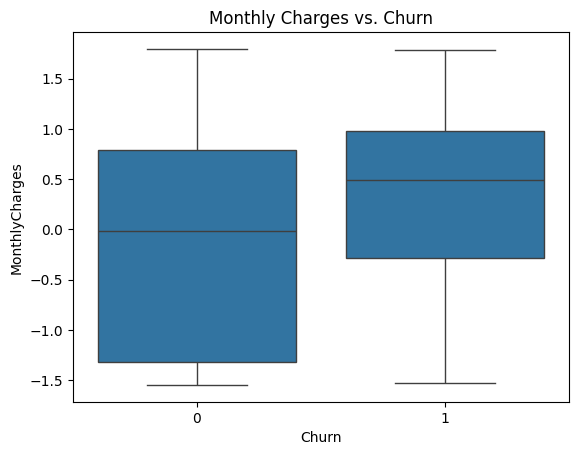

In [95]:
# Monthly Charges vs Churn

sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges vs. Churn')
plt.show()

Text(0.5, 1.0, 'Overall Churn Percentage')

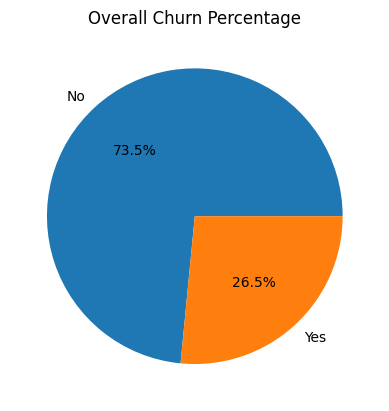

In [133]:
# percentage of customers have churned

plt.pie(df['Churn'].value_counts(), labels=['No', 'Yes'], autopct='%1.1f%%')
plt.title('Overall Churn Percentage')

<Axes: >

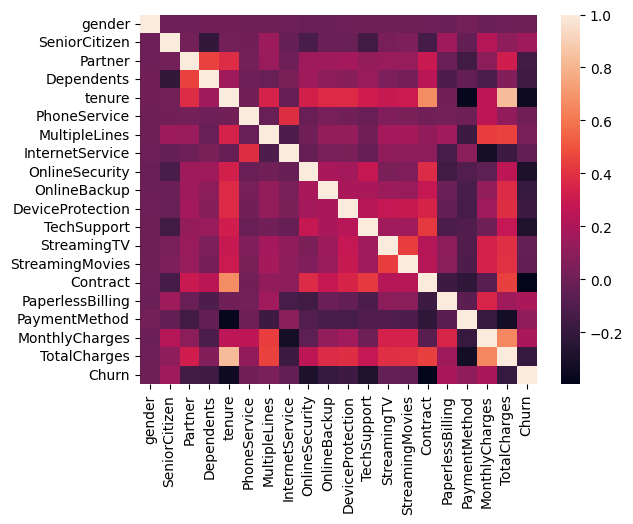

In [134]:
#features correlate most 

sns.heatmap(df.corr())

Text(0.5, 1.0, 'Churn by Contract Type')

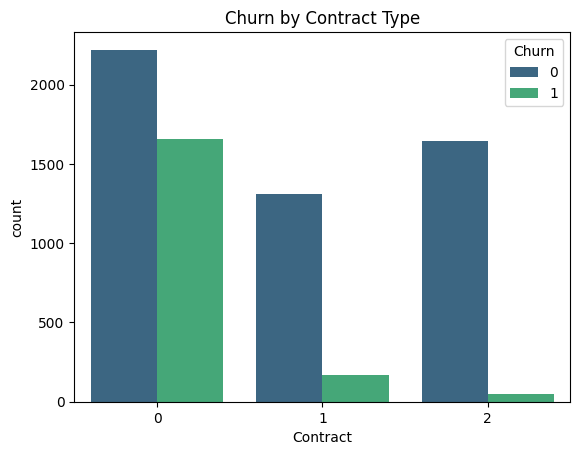

In [97]:
# contract type has the highest churn
plt.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Churn by Contract Type')

Model Building 

In [98]:
#importing train test split library

from sklearn.model_selection import train_test_split

In [99]:
#defining target and splitting data 80 percent training(X) and 20 percent testing(y)

X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 ,random_state = 42)

In [112]:
#Logistic Regression

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
f"Logistic Regression Accuracy: {accuracy_score(y_test, lr.predict(X_test)):.2%}"

'Logistic Regression Accuracy: 81.76%'

In [110]:
#Random Forest

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)
f"Random Forest Accuracy: {accuracy_score(y_test, rf.predict(X_test)):.2%}"

'Random Forest Accuracy: 79.63%'

In [129]:
# checking accuracy score

from sklearn.metrics import accuracy_score  
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2%}")

Accuracy:  79.63%


In [130]:
# checking precision_score

from sklearn.metrics import precision_score
print(f"Precision: {precision_score(y_test, y_pred):.2%}")

Precision: 66.29%


In [123]:
# checking recall_score

from sklearn.metrics import recall_score
print(f"Recall:    {recall_score(y_test, y_pred):.2%}")

Recall:    46.92%


In [126]:
# checking f1_score

from sklearn.metrics import f1_score
print(f"F1 Score:  {f1_score(y_test, y_pred):.2%}")

F1 Score:  54.95%


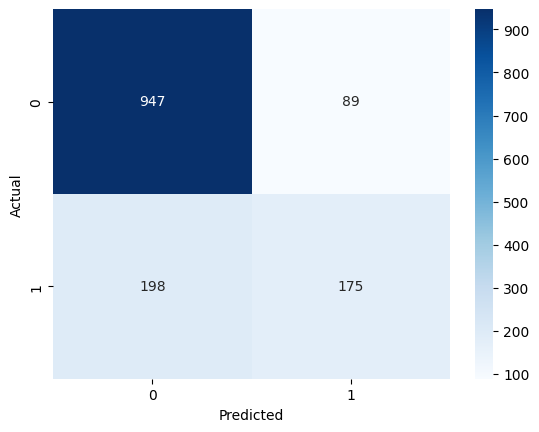

In [131]:
# checking confusion_matrix

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
-------------------------------------------------------------------------------------------